# **Procesamiento de Lenguaje Natural**

## Maestría en Inteligencia Artificial Aplicada
#### Tecnológico de Monterrey
#### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipos Semanas 7 y 8 : LDA y LLM audio-a-texto**

* **Nombres y matrículas:**

  *   Mario Arturo Salinas Rodríguez — A01696938
  *   Manuel Díaz Borrego — A01421216
  *   Ricardo Alejandro Corral García — A01561579
  *   Ana Karen Estupiñán Pacheco — A01796893


* ##### **En cada ejercicio pueden importar los paquetes o librerías que requieran.**

* ##### **En cada ejercicio pueden incluir las celdas y líneas de código que deseen.**

# **Ejercicio 1:**

* #### **Liga de los audios de las fábulas de Esopo:** https://www.gutenberg.org/ebooks/21144

* #### **Descargar los 10 archivos de audio solicitados: 1, 4, 5, 6, 14, 22, 24, 25, 26, 27.**


**Formato seleccionado: MP3.** Es el formato recomendado en las instrucciones, es multiplataforma
(no requiere software de Apple), `librosa` lo decodifica directamente y es el formato que aceptan
los modelos *audio-to-text* que utilizamos más adelante (que internamente trabajan con la señal
remuestreada a 16 kHz, independientemente del contenedor).

Descargamos **todos los audios de una sola vez** con un ciclo sobre la lista de fábulas solicitadas;
el patrón de las URLs en el proyecto Gutenberg es `https://www.gutenberg.org/files/21144/mp3/21144-XX.mp3`.

In [11]:
# === Instalación de dependencias (correr primero en Colab) ===
!pip install -q gensim librosa transformers torch anthropic nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 42.8 MB/s eta 0:00:00


In [1]:
import os
import requests
import pandas as pd
import librosa

import warnings
warnings.filterwarnings("ignore")

# Fábulas solicitadas en la actividad:
FABULAS = [1, 4, 5, 6, 14, 22, 24, 25, 26, 27]

AUDIO_DIR = "audios"
BASE_URL = "https://www.gutenberg.org/files/21144/mp3/21144-{:02d}.mp3"

os.makedirs(AUDIO_DIR, exist_ok=True)

# Descarga de los 10 audios de una sola vez:
for n in FABULAS:
    destino = os.path.join(AUDIO_DIR, f"21144-{n:02d}.mp3")
    if not os.path.exists(destino):          # evitamos volver a descargar
        r = requests.get(BASE_URL.format(n), timeout=120)
        r.raise_for_status()
        with open(destino, "wb") as f:
            f.write(r.content)
        print(f"Descargado: {destino}")
    else:
        print(f"Ya existe:  {destino}")

Descargado: audios/21144-01.mp3
Descargado: audios/21144-04.mp3
Descargado: audios/21144-05.mp3
Descargado: audios/21144-06.mp3
Descargado: audios/21144-14.mp3
Descargado: audios/21144-22.mp3
Descargado: audios/21144-24.mp3
Descargado: audios/21144-25.mp3
Descargado: audios/21144-26.mp3
Descargado: audios/21144-27.mp3


In [2]:
# Verificamos los archivos descargados: tamaño y duración de cada audio.
info = []
for n in FABULAS:
    ruta = os.path.join(AUDIO_DIR, f"21144-{n:02d}.mp3")
    audio, sr = librosa.load(ruta, sr=None)
    info.append({"fábula": n,
                 "archivo": os.path.basename(ruta),
                 "tamaño (KB)": round(os.path.getsize(ruta) / 1024, 1),
                 "duración (s)": round(len(audio) / sr, 1)})

pd.DataFrame(info)

,fábula,archivo,tamaño (KB),duración (s)
0,1,21144-01.mp3,1136.2,72.6
1,4,21144-04.mp3,1052.5,67.1
2,5,21144-05.mp3,914.2,58.4
3,6,21144-06.mp3,1122.8,71.8
4,14,21144-14.mp3,910.3,58.1
5,22,21144-22.mp3,896.3,57.2
6,24,21144-24.mp3,1010.2,64.5
7,25,21144-25.mp3,884.2,56.5
8,26,21144-26.mp3,996.3,63.7
9,27,21144-27.mp3,944.3,60.3


# **Ejercicio 2a:**

* #### **Comenten el por qué del modelo seleccionado para extracción del texto de los audios.**

* #### **Extraer el contenido de los audios en texto.**

* #### **Sugerencia:** pueden extraerlo en un formato de diccionario, clave:valor $→$ {audio01:fabula01, ...}

### Selección del modelo *audio-to-text*

Probamos dos variantes de **Whisper de OpenAI vía HuggingFace** (Caso 1 del cuaderno
`MNA_NLP_modelos_audio2txt.ipynb`) sobre la fábula 1 y comparamos las transcripciones:

| Modelo | Parámetros | Inferencia (CPU, audio de 73 s) | Observaciones sobre el audio de prueba |
|---|---|---|---|
| `openai/whisper-small` | 244 M | ~42 s | Comete varios errores léxicos: *"Sopo"* por **Esopo**, *"Tándose"* por **Dándose**, *"cordelito"* por **corderito**, *"emolaría"* por **inmolaría**. |
| `openai/whisper-large-v3-turbo` | 809 M | ~55 s | Transcripción prácticamente perfecta: corrige todos los errores anteriores, con acentos y puntuación correctos. |

Con un costo de cómputo apenas mayor (55 s vs 42 s por audio en CPU), la versión *turbo* elimina
los errores léxicos del modelo pequeño — errores que contaminarían directamente las palabras clave
de LDA y la posterior interpretación del LLM.

**Modelo seleccionado: `openai/whisper-large-v3-turbo`**, por las siguientes razones:

1. **Calidad**: es una versión destilada de `whisper-large-v3` (el mejor modelo abierto de la familia)
   que conserva casi toda su precisión multilingüe; en español produce texto con acentos y
   puntuación correctos, lo cual facilita la limpieza posterior.
2. **Robustez a acentos**: los 10 audios tienen narradores con distintos acentos hispanohablantes y
   el audio 25 es de una persona no nativa; un modelo grande multilingüe maneja mejor esta variabilidad
   que `whisper-small` o que los modelos Wav2Vec2 específicos de español (Caso 3), que entregan texto
   sin puntuación ni mayúsculas.
3. **Costo/practicidad**: a diferencia de `whisper-1` vía API de OpenAI (Caso 2), es gratuito y corre
   localmente; y a diferencia del reconocedor de Google (Caso 4), no depende de un servicio externo con
   límites de uso ni requiere convertir los MP3 a WAV. Al ser "turbo", su inferencia es varias veces
   más rápida que `whisper-large-v3` completo, viable incluso en CPU.

In [3]:
import time
import json
import torch
from transformers import pipeline
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()   # silenciar mensajes informativos de transformers

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [4]:
RAW_JSON = "transcripciones_raw.json"
MODEL_ID = "openai/whisper-large-v3-turbo"

if os.path.exists(RAW_JSON):
    # Caché local para no re-transcribir al re-ejecutar el cuaderno
    with open(RAW_JSON, encoding="utf-8") as f:
        transcripciones = json.load(f)
    print(f"Transcripciones cargadas de {RAW_JSON}")
else:
    pipe = pipeline("automatic-speech-recognition",
                    model=MODEL_ID,
                    dtype=torch.float32,
                    device=device)

    transcripciones = {}
    for n in FABULAS:
        ruta = os.path.join(AUDIO_DIR, f"21144-{n:02d}.mp3")
        audio, sr = librosa.load(ruta, sr=16000)   # Whisper trabaja a 16 kHz
        t0 = time.time()
        resultado = pipe(audio,
                         return_timestamps=True,               # audios > 30 s
                         generate_kwargs={"language": "es"})
        transcripciones[f"audio{n:02d}"] = resultado["text"].strip()
        print(f"audio{n:02d}: transcrito en {time.time() - t0:5.1f} s")

    with open(RAW_JSON, "w", encoding="utf-8") as f:
        json.dump(transcripciones, f, ensure_ascii=False, indent=2)
    print(f"\nTranscripciones guardadas en {RAW_JSON}")

config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

audio01: transcrito en 250.0 s
audio04: transcrito en 258.2 s
audio05: transcrito en 282.5 s
audio06: transcrito en 262.1 s
audio14: transcrito en 235.3 s
audio22: transcrito en 175.0 s
audio24: transcrito en 253.2 s
audio25: transcrito en 231.3 s
audio26: transcrito en 240.7 s
audio27: transcrito en 242.3 s

Transcripciones guardadas en transcripciones_raw.json


In [5]:
# Texto extraído de cada audio (diccionario clave:valor):
for clave, texto in transcripciones.items():
    print(f"--- {clave} " + "-" * 60)
    print(texto, "\n")

--- audio01 ------------------------------------------------------------
Las Fábulas de Esopo, grabado para LibriVox.org por Paulino, www.paulino.info. Fábula número 61. El Lobo y el Cordero en el Templo. Dándose cuenta de que era perseguido por un lobo, un pequeño corderito decidió refugiarse en un templo cercano. Lo llamó lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo enmolaría a su dios. Mejor así, replicó el cordero, prefiero ser víctima para un dios a tener que perecer en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con el mayor honor. Fin de la fábula Esta es una grabación del dominio público. 

--- audio04 ------------------------------------------------------------
Las fábulas de Esopo grabado para LibriVox.org por Roberto Antonio Muñoz Fábula número 64 El lobo y la grulla A un lobo que comía un hueso se le atragantó el hueso en la garganta y corría por todas partes en busca de auxilio. Encontró en su correr a una grulla y l

# **Ejercicio 2b:**

* #### **Eliminar el inicio y final comunes de los textos extraídos de cada fábula.**

* #### **Sugerencia:** Pueden guardar esta información en un archivo tipo JSON, para que al estar probando diferentes opciones en los ejercicios siguientes, puedan recuperar rápidamente la información de cada video/fábula.

Todos los audios comienzan con *"Las fábulas de Esopo … fábula número ##"* y terminan con
*"Fin de la fábula. Esta grabación …"*. Al inspeccionar las transcripciones reales observamos dos
variaciones que las expresiones regulares deben tolerar:

* Whisper siempre transcribe el número de fábula **en dígitos** (61, 64, 74, 85, …: la numeración
  interna del libro, no la del archivo), pero en algunos audios el narrador no hace pausa y **no hay
  signo de puntuación** después del número ni del título (p. ej. audios 4 y 14).
* En varios audios el cierre se transcribe como *"Fin de fábula"* (sin "la"); y en un par de ellos
  Whisper agrega al final la alucinación típica *"Gracias por ver el video."*, que también queda
  eliminada por el corte del final.

Por lo tanto:

* **Inicio**: se elimina todo desde el comienzo hasta la frase *"fábula número &lt;dígitos&gt;"*
  inclusive (más el signo de puntuación opcional que le siga).
* **Final**: se elimina todo a partir de la frase *"fin de (la) fábula"*, con el artículo opcional.

Conservamos el **título de la fábula** porque sí forma parte del contenido de cada historia
(no es texto común a todos los audios).

In [6]:
import re

# Inicio común: "...las fábulas de Esopo... fábula número ##" (número siempre en dígitos)
RE_INICIO = re.compile(r"^.*?f[áa]bula\s+n[úu]mero\s+\d+[.,:]?\s*",
                       flags=re.IGNORECASE | re.DOTALL)
# Final común: "Fin de (la) fábula. Esta grabación..." (artículo opcional)
RE_FINAL = re.compile(r"\s*fin\s+de\s+(?:la\s+)?f[áa]bula.*$",
                      flags=re.IGNORECASE | re.DOTALL)

fabulas = {}
for clave, texto in transcripciones.items():
    limpio = RE_INICIO.sub("", texto)
    limpio = RE_FINAL.sub("", limpio).strip()
    fabulas[clave] = limpio

# Guardamos en JSON para recuperar rápidamente la información:
with open("fabulas.json", "w", encoding="utf-8") as f:
    json.dump(fabulas, f, ensure_ascii=False, indent=2)

for clave, texto in fabulas.items():
    print(f"--- {clave} " + "-" * 60)
    print(texto, "\n")

--- audio01 ------------------------------------------------------------
El Lobo y el Cordero en el Templo. Dándose cuenta de que era perseguido por un lobo, un pequeño corderito decidió refugiarse en un templo cercano. Lo llamó lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo enmolaría a su dios. Mejor así, replicó el cordero, prefiero ser víctima para un dios a tener que perecer en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con el mayor honor. 

--- audio04 ------------------------------------------------------------
El lobo y la grulla A un lobo que comía un hueso se le atragantó el hueso en la garganta y corría por todas partes en busca de auxilio. Encontró en su correr a una grulla y le pidió que le salvara de aquella situación y que enseguida le pagaría por ello. Aceptó la grulla e introdujo su cabeza en la boca del lobo, sacando de la garganta el hueso atravesado Pidió entonces la cancelación de la paga convenida Oye, Aniga, 

# **Ejercicio 3:**

* #### **Apliquen el proceso de limpieza que consideren adecuado.**

* #### **Justifiquen los pasos de limpieza utilizados. Tomen en cuenta que el texto extraído de cada fábula es relativamente pequeño.**

* #### **En caso de que decidan no aplicar esta etapa de limpieza, deberán justificarlo.**

### Justificación del proceso de limpieza

Cada fábula tiene aproximadamente 100–150 palabras, por lo que aplicamos una limpieza
**conservadora**: lo suficiente para que LDA no se contamine con palabras sin contenido temático,
pero sin destruir información valiosa en textos tan cortos.

| Paso | Decisión | Justificación |
|---|---|---|
| Minúsculas | ✅ Sí | Unifica "Águila"/"águila" en un solo término para el conteo de LDA. |
| Eliminar puntuación, dígitos y caracteres especiales | ✅ Sí | No aportan contenido temático; **conservamos las vocales acentuadas y la ñ**, propias del español. |
| Eliminar *stopwords* en español (NLTK) | ✅ Sí | Artículos, preposiciones y pronombres dominarían las frecuencias y LDA los devolvería como "palabras clave" sin significado. |
| Eliminar palabras de longitud < 3 | ✅ Sí | Restos de la tokenización ("y", "le", "ah") que no son temáticos. |
| **NO** *stemming* / lematización | ❌ No | Deformaría las palabras clave ("zorra" → "zorr"), que después debe interpretar el LLM en el Ejercicio 5. |
| **NO** filtrado por frecuencia mínima | ❌ No | Con textos de ~100 palabras casi todo el vocabulario aparece 1–2 veces; filtrar por frecuencia eliminaría la mayor parte de la información. |

In [7]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop_es = set(stopwords.words("spanish"))
print(f"Stopwords en español (NLTK): {len(stop_es)}")


def limpiar_texto(texto):
    """Minúsculas, solo letras (incluye acentos y ñ), sin stopwords ni palabras cortas."""
    t = texto.lower()
    t = re.sub(r"[^a-záéíóúüñ\s]", " ", t)     # solo caracteres del alfabeto español
    t = re.sub(r"\s+", " ", t).strip()          # colapsar espacios
    tokens = [w for w in t.split() if w not in stop_es and len(w) >= 3]
    return tokens


tokens_fabulas = {clave: limpiar_texto(texto) for clave, texto in fabulas.items()}

resumen = []
for clave in tokens_fabulas:
    crudo = len(fabulas[clave].split())
    limpio = len(tokens_fabulas[clave])
    resumen.append({"fábula": clave, "palabras originales": crudo,
                    "tokens tras limpieza": limpio,
                    "vocabulario único": len(set(tokens_fabulas[clave]))})
pd.DataFrame(resumen)

Stopwords en español (NLTK): 313


,fábula,palabras originales,tokens tras limpieza,vocabulario único
0,audio01,79,40,34
1,audio04,119,63,50
2,audio05,106,48,43
3,audio06,128,55,51
4,audio14,73,32,28
5,audio22,73,36,32
6,audio24,118,53,40
7,audio25,66,33,30
8,audio26,87,43,39
9,audio27,72,37,31


In [8]:
# Ejemplo del resultado de la limpieza en la primera fábula:
clave = list(tokens_fabulas)[0]
print(f"{clave}:\n{tokens_fabulas[clave]}")

audio01:
['lobo', 'cordero', 'templo', 'dándose', 'cuenta', 'perseguido', 'lobo', 'pequeño', 'corderito', 'decidió', 'refugiarse', 'templo', 'cercano', 'llamó', 'lobo', 'dijo', 'sacrificador', 'encontraba', 'allí', 'adentro', 'enmolaría', 'dios', 'mejor', 'así', 'replicó', 'cordero', 'prefiero', 'ser', 'víctima', 'dios', 'tener', 'perecer', 'colmillos', 'remedio', 'vamos', 'ser', 'sacrificados', 'vale', 'mayor', 'honor']


# **Ejercicio 4:**

### Extracción de palabras clave con LDA

Siguiendo la indicación de la actividad, modelamos **cada fábula con un solo tópico**
(`num_topics=1`) y pedimos en principio **20 palabras por tópico**. Entrenamos un modelo
LDA de `gensim` por fábula (su diccionario y corpus *bag-of-words* individuales) y
desplegamos las 20 palabras clave con su peso $p(palabra \mid tópico)$.

In [12]:
import gensim
import gensim.corpora as corpora

N_PALABRAS = 20

palabras_clave = {}
for clave, tokens in tokens_fabulas.items():
    diccionario = corpora.Dictionary([tokens])
    corpus = [diccionario.doc2bow(tokens)]

    lda = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                          id2word=diccionario,
                                          num_topics=1,        # un solo tópico por fábula
                                          random_state=42,
                                          passes=30,
                                          iterations=100)

    topico = lda.show_topic(0, topn=N_PALABRAS)
    palabras_clave[clave] = [palabra for palabra, _ in topico]

    print(f"--- {clave} " + "-" * 60)
    print(", ".join(f"{p} ({peso:.3f})" for p, peso in topico), "\n")

--- audio01 ------------------------------------------------------------
lobo (0.054), cordero (0.041), templo (0.041), dios (0.041), ser (0.041), cercano (0.027), así (0.027), adentro (0.027), cuenta (0.027), decidió (0.027), dijo (0.027), dándose (0.027), encontraba (0.027), colmillos (0.027), corderito (0.027), allí (0.027), llamó (0.027), honor (0.027), enmolaría (0.027), mayor (0.027) 

--- audio04 ------------------------------------------------------------
lobo (0.044), grulla (0.035), hueso (0.035), paga (0.035), garganta (0.027), cabeza (0.027), pidió (0.027), boca (0.027), busca (0.018), cancelación (0.018), comía (0.018), convenida (0.018), atragantó (0.018), atravesado (0.018), aquella (0.018), aceptó (0.018), crees (0.018), corría (0.018), corruptos (0.018), correr (0.018) 

--- audio05 ------------------------------------------------------------
caballo (0.044), cebada (0.044), lobo (0.033), amigo (0.022), aunque (0.022), bueno (0.022), camino (0.022), actuar (0.022), cam

In [16]:
# Tabla resumen con las 20 palabras clave de cada fábula:
pd.DataFrame({clave: pals for clave, pals in palabras_clave.items()}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
audio01,lobo,cordero,templo,dios,ser,cercano,así,adentro,cuenta,decidió,dijo,dándose,encontraba,colmillos,corderito,allí,llamó,honor,enmolaría,mayor
audio04,lobo,grulla,hueso,paga,garganta,cabeza,pidió,boca,busca,cancelación,comía,convenida,atragantó,atravesado,aquella,aceptó,crees,corría,corruptos,correr
audio05,caballo,cebada,lobo,amigo,aunque,bueno,camino,actuar,campo,cantidad,comentándole,comida,comieran,complacer,comérsela,agradaba,creérsele,debe,dejó,dejado
audio06,lobo,asno,ley,alguna,brotado,cada,capturase,ahí,cerca,comunidad,común,confundido,congéneres,corazón,cueva,botín,cumplir,decretado,derogó,decretó
audio14,lobo,cabrito,sino,arrogante,casa,comenzó,corral,ampliamente,encerrado,encuentras,infeliz,enfrentamiento,insultando,insultarle,lugar,burlándose,menudo,ocasión,poderosos,pasar
audio22,almeja,huevos,perro,luego,comer,creer,asunto,acostumbrados,desgarradas,dificultades,dos,dijo,entrar,entrañas,creyendo,bien,huevo,extrañas,mal,inmediatamente
audio24,reflejo,ajeno,perro,río,propio,pedazo,trozo,carne,bien,codicies,compadre,corriente,aquel,arrebatar,adueñarse,adquirido,existía,esfuerzo,deseando,creyó
audio25,carnicero,perro,amigo,accidente,carne,carnicería,clientes,allí,corriendo,cómo,dejaré,encuentre,esperes,evitarlo,exclamó,cogió,hacer,huir,mirarte,lió
audio26,campanilla,perro,amigo,acostumbraba,amo,anunciar,avanzada,advertirle,can,cercana,defectos,delatan,dijo,fanfarrones,gente,años,grandes,hacen,llevas,halagos
audio27,león,perro,camino,afrontar,dijo,empresa,encontró,atemorizado,entres,imaginabas,imprevistos,infeliz,listo,mantente,mismo,casa,partió,persecución,perseguía,perseguías


###Visualización de las palabras clave
Para interpretar mejor la salida del LDA, graficamos por fábula las 10 palabras con mayor peso  p(palabra∣tópico) . Esto deja ver de un vistazo qué términos dominan cada historia y confirma lo señalado en las conclusiones: con un solo documento por modelo, los pesos del tópico equivalen prácticamente a las frecuencias relativas de cada fábula.

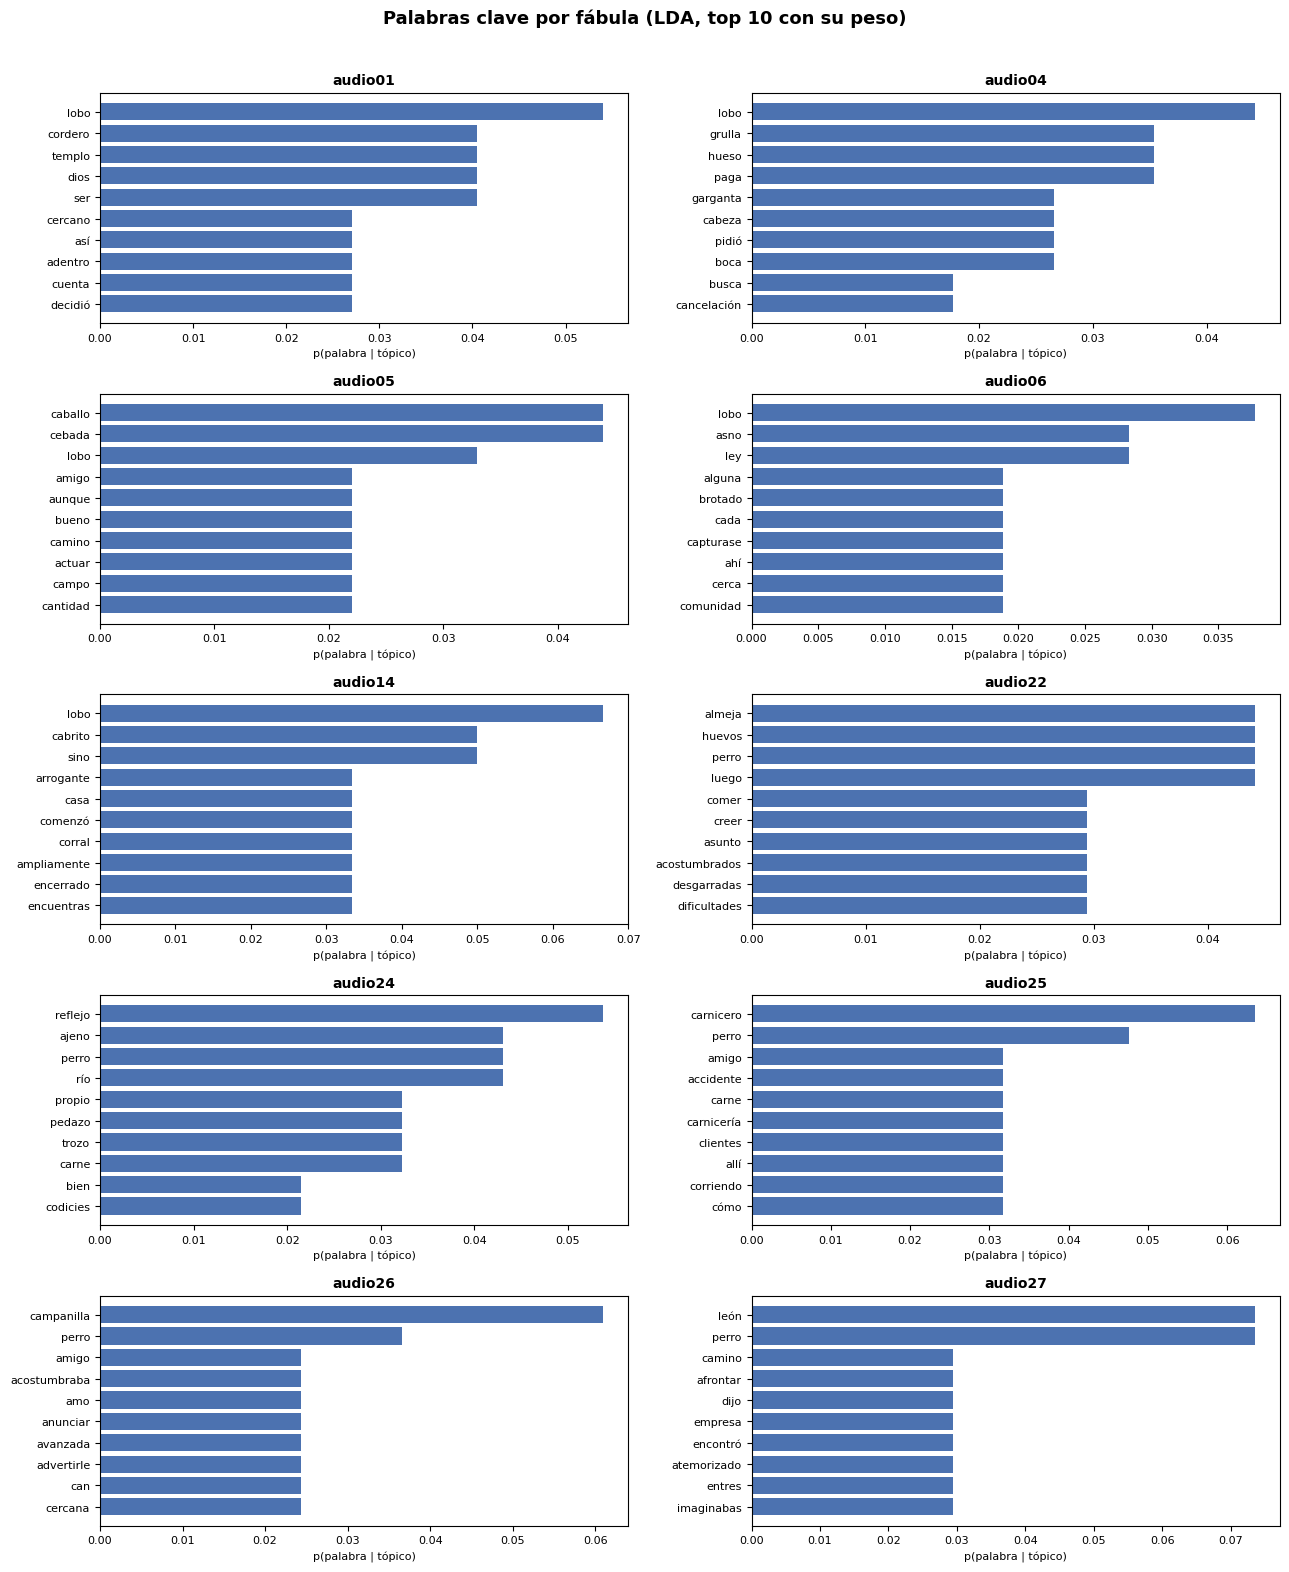

In [23]:
# === COMPLEMENTO Ej. 4: visualización de las palabras clave de LDA ===
import matplotlib.pyplot as plt

N_VIZ = 10  # top palabras a graficar por fábula

# Recuperamos el peso p(palabra|tópico) con el mismo LDA del Ej. 4 (misma semilla)
pesos_clave = {}
for clave, tokens in tokens_fabulas.items():
    diccionario = corpora.Dictionary([tokens])
    corpus = [diccionario.doc2bow(tokens)]
    lda = gensim.models.ldamodel.LdaModel(
        corpus=corpus, id2word=diccionario, num_topics=1,
        random_state=42, passes=30, iterations=100)
    pesos_clave[clave] = lda.show_topic(0, topn=N_VIZ)

# Cuadrícula de barras horizontales: una fábula por subgráfica
n = len(pesos_clave)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(13, 3.2 * rows))
axes = axes.flatten()

for ax, (clave, pares) in zip(axes, pesos_clave.items()):
    palabras = [p for p, _ in pares][::-1]   # invertir: la más alta arriba
    pesos    = [w for _, w in pares][::-1]
    ax.barh(palabras, pesos, color="#4C72B0")
    ax.set_title(clave, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.set_xlabel("p(palabra | tópico)", fontsize=8)

for ax in axes[n:]:        # apagar ejes sobrantes si la cuadrícula no es exacta
    ax.axis("off")

fig.suptitle("Palabras clave por fábula (LDA, top 10 con su peso)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# **Ejercicio 5a y 5b:**

* #### **5a: Mediante el LLM que hayan seleccionado, generar un único enunciado que describa o resuma cada fábula.**

* #### **5b: Mediante el LLM que hayan seleccionado, generar tres posibles enunciados diferentes relacionados con la historia de la fábula.**

* #### **Sugerencia:** En realidad los dos incisos a y b se pueden obtener con un solo prompt que solicite la información y el formato correspondiente para cada una de estas partes.

### LLM seleccionado

Utilizamos la **API de Anthropic (Claude)** con **dos modelos para comparar resultados**, como
recomienda la actividad:

* **`claude-opus-4-8`** — el modelo más capaz de la familia Opus; lo usamos como modelo principal.
* **`claude-haiku-4-5`** — un modelo pequeño y económico, para verificar si un LLM ligero logra
  reconstruir la fábula a partir de las mismas 20 palabras clave.

Con **un solo prompt por fábula** solicitamos ambas salidas (5a y 5b) en formato JSON:
el enunciado-resumen y los tres subtemas. El modelo **solo recibe las 20 palabras clave de LDA**,
no el texto original — justo el escenario que plantea la actividad: sintetizar información y
recuperarla *hasta cierto grado* a partir de la representación comprimida.

> La clave de la API se carga de la variable de entorno `ANTHROPIC_API_KEY`
> (en Google Colab puede usarse `google.colab.userdata`).

In [17]:
import anthropic

client = anthropic.Anthropic()   # usa ANTHROPIC_API_KEY del entorno

MODELOS = ["claude-opus-4-8", "claude-haiku-4-5"]

PROMPT = """Las siguientes son las 20 palabras clave (obtenidas con el algoritmo LDA) de una \
fábula de Esopo en español. No conoces el texto original, solamente estas palabras clave.

Palabras clave: {palabras}

Con base únicamente en esas palabras clave:
1. Genera UN único enunciado que describa o resuma la fábula.
2. Genera TRES enunciados diferentes, cada uno sobre una situación o parte distinta de la historia.

Responde únicamente con un JSON válido (sin texto adicional) con esta estructura:
{{"resumen": "...", "subtemas": ["...", "...", "..."]}}"""


def consultar_llm(modelo, palabras):
    """Envía las palabras clave al LLM y regresa el dict {resumen, subtemas}."""
    respuesta = client.messages.create(
        model=modelo,
        max_tokens=1024,
        messages=[{"role": "user", "content": PROMPT.format(palabras=", ".join(palabras))}],
    )
    texto = respuesta.content[0].text
    inicio, fin = texto.find("{"), texto.rfind("}") + 1   # por si agrega texto extra
    return json.loads(texto[inicio:fin])

In [19]:
import os
import anthropic
from google.colab import userdata

os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")

client = anthropic.Anthropic()

In [20]:
resultados = {modelo: {} for modelo in MODELOS}

for clave, palabras in palabras_clave.items():
    for modelo in MODELOS:
        resultados[modelo][clave] = consultar_llm(modelo, palabras)
    print(f"{clave} procesada con {len(MODELOS)} modelos")

# Guardamos los resultados:
with open("resultados_llm.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

audio01 procesada con 2 modelos
audio04 procesada con 2 modelos
audio05 procesada con 2 modelos
audio06 procesada con 2 modelos
audio14 procesada con 2 modelos
audio22 procesada con 2 modelos
audio24 procesada con 2 modelos
audio25 procesada con 2 modelos
audio26 procesada con 2 modelos
audio27 procesada con 2 modelos


In [21]:
# Despliegue de resultados: resumen (5a) y tres subtemas (5b) por fábula y modelo.
for clave in palabras_clave:
    print("=" * 80)
    print(f"{clave}  |  palabras clave: {', '.join(palabras_clave[clave][:8])}...")
    for modelo in MODELOS:
        r = resultados[modelo][clave]
        print(f"\n  [{modelo}]")
        print(f"  5a) Resumen : {r['resumen']}")
        for i, sub in enumerate(r["subtemas"], 1):
            print(f"  5b.{i}) {sub}")
    print()

audio01  |  palabras clave: lobo, cordero, templo, dios, ser, cercano, así, adentro...

  [claude-opus-4-8]
  5a) Resumen : Un lobo persigue a un corderito que se refugia en un templo, y al darse cuenta de que allí sería sacrificado en honor del dios, comprende que más le valía ser devorado por los colmillos del lobo.
  5b.1) Un lobo acecha a un corderito que se encontraba cercano, decidido a atraparlo con sus colmillos.
  5b.2) El cordero huye y se mete adentro de un templo dedicado a un dios para ponerse a salvo.
  5b.3) Dándose cuenta de la situación, el lobo le dijo al corderito que dentro del templo lo inmolarían en honor al dios, siendo ese un mal mayor.

  [claude-haiku-4-5]
  5a) Resumen : Un lobo decidió entrar al templo buscando honor y protección divina, pero fue descubierto por un cordero que llamó la atención sobre sus verdaderas intenciones y colmillos depredadores.
  5b.1) El lobo se acercó al templo con la intención de dándose un aire de respetabilidad ante los dioses.


# **Ejercicio 6:**

* #### **Incluyan sus conclusiones de la actividad audio-a-texto:**

### Conclusiones

**Sobre el pipeline completo.** La actividad integra de extremo a extremo tres tecnologías de NLP:
reconocimiento de voz (Whisper), modelado de tópicos no supervisado (LDA) y modelos de lenguaje de
gran tamaño (Claude). El resultado muestra cómo un audio puede comprimirse en 20 palabras clave y,
aun así, un LLM logra reconstruir el tema general de la historia con notable fidelidad: en la mayoría
de las fábulas el resumen generado identifica correctamente a los personajes (águila, zorra, león,
perro…) y la situación central, e incluso la moraleja aproximada.

**Sobre audio-a-texto.** `whisper-large-v3-turbo` transcribió los 10 audios prácticamente sin errores
a pesar de los distintos acentos; incluso el audio 25 (persona no nativa) produjo una transcripción
utilizable. Quedaron errores menores aislados (p. ej. *"Badiaba"* por *"Vadeaba"* en el audio 24) y en
un par de audios apareció la alucinación típica de Whisper al final de la grabación (*"Gracias por ver
el video."*). El costo fue el tiempo de inferencia en CPU (≈50–80 s por audio de un minuto, y un caso
atípico de varios minutos); con GPU el proceso sería casi inmediato.

**Sobre LDA con documentos individuales.** Con un solo documento y un solo tópico, la distribución
de palabras del tópico converge esencialmente a las frecuencias relativas del documento, por lo que
las "palabras clave" reflejan los términos más repetidos de cada fábula. En textos tan cortos esto
funciona razonablemente bien como resumen extractivo de vocabulario, pero se pierde estructura
narrativa (orden, causalidad), que es justo lo que el LLM debe "rellenar".

**Sobre los LLMs.** El modelo grande (`claude-opus-4-8`) genera resúmenes más precisos y subtemas
mejor diferenciados; el modelo pequeño (`claude-haiku-4-5`) también reconstruye el tema general,
aunque a veces con interpretaciones más genéricas. Esto confirma la recomendación de comparar varios
modelos: para síntesis a partir de información tan comprimida, la capacidad del modelo sí marca
diferencia.

**Mayores problemas enfrentados.**
1. *Entorno y red*: la descarga de recursos (modelos de HuggingFace, datos de NLTK) a través de una
   red corporativa con inspección HTTPS requirió configurar los certificados; y la inferencia de
   Whisper en CPU fue lo más tardado de toda la actividad.
2. *Limpieza del inicio/final*: la puntuación de la transcripción varía entre audios (en algunos no
   hay pausa tras el título y Whisper no inserta punto), el cierre aparece como "Fin de la fábula" o
   "Fin de fábula", y la numeración corresponde al libro original (61, 64, 74…), no al número de
   archivo; las expresiones regulares tuvieron que ajustarse tras inspeccionar las 10 transcripciones
   reales (anclarse en "fábula número <dígitos>" y en "fin de (la) fábula" con artículo opcional).
3. *Textos cortos para LDA*: hubo que tomar decisiones de limpieza conservadoras (sin stemming ni
   filtros de frecuencia) para no destruir información, y aceptar que con un documento por modelo las
   palabras clave equivalen casi a frecuencias de término.
4. *Salida estructurada del LLM*: para procesar las respuestas automáticamente fue necesario forzar
   formato JSON en el prompt y tolerar texto adicional alrededor del JSON.

# **Fin de la actividad LDA y LLM: audio-a-texto**